In [ ]:
import os
import shutil
from collections import defaultdict
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================

ROOT_DIR = "UCF3Class"

OUTPUT_DIR = "UCF3Class_Balanced"

SPLITS = ["Train", "Test"]

FRAME_EXTENSIONS = (".png", ".jpg", ".jpeg")

MIN_FRAMES = 16

# Optional:
# TARGET_VIDEOS_PER_CLASS = 500
TARGET_VIDEOS_PER_CLASS = None

# =========================================================
# VIDEO ID EXTRACTION
# =========================================================

def extract_video_id(filename):

    """
    Example:
    Fighting051_x264_6350.png
    ->
    Fighting051_x264
    """

    parts = filename.split("_")

    if len(parts) < 3:
        return None

    return "_".join(parts[:-1])

# =========================================================
# BUILD VIDEO INDEX
# =========================================================

def build_video_index(class_dir):

    video_dict = defaultdict(list)

    files = sorted(os.listdir(class_dir))

    for file in files:

        if not file.lower().endswith(FRAME_EXTENSIONS):
            continue

        video_id = extract_video_id(file)

        if video_id is None:
            continue

        video_dict[video_id].append(file)

    # remove tiny videos
    filtered = {}

    for vid, frames in video_dict.items():

        if len(frames) >= MIN_FRAMES:
            filtered[vid] = sorted(frames)

    return filtered

# =========================================================
# PROCESS EACH SPLIT
# =========================================================

for split in SPLITS:

    print(f"\n========== {split.upper()} ==========\n")

    split_path = os.path.join(ROOT_DIR, split)

    class_video_map = {}

    # =====================================================
    # ANALYZE CLASSES
    # =====================================================

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        videos = build_video_index(class_path)

        class_video_map[class_name] = videos

        total_frames = sum(len(v) for v in videos.values())

        print(f"{class_name}")
        print(f"  Videos : {len(videos)}")
        print(f"  Frames : {total_frames}")
        print()

    # =====================================================
    # DETERMINE TARGET BALANCE
    # =====================================================

    video_counts = {
        cls: len(videos)
        for cls, videos in class_video_map.items()
    }

    min_videos = min(video_counts.values())

    target_videos = (
        TARGET_VIDEOS_PER_CLASS
        if TARGET_VIDEOS_PER_CLASS is not None
        else min_videos
    )

    print(f"Balancing to {target_videos} videos/class\n")

    # =====================================================
    # COPY BALANCED DATA
    # =====================================================

    for class_name, videos in class_video_map.items():

        output_class_dir = os.path.join(
            OUTPUT_DIR,
            split,
            class_name
        )

        os.makedirs(output_class_dir, exist_ok=True)

        selected_video_ids = sorted(videos.keys())[:target_videos]

        print(f"Processing {class_name}")
        print(f"Selected videos: {len(selected_video_ids)}")

        copied_frames = 0

        for vid in tqdm(selected_video_ids):

            frames = videos[vid]

            for frame_name in frames:

                src = os.path.join(
                    ROOT_DIR,
                    split,
                    class_name,
                    frame_name
                )

                dst = os.path.join(
                    output_class_dir,
                    frame_name
                )

                shutil.copy2(src, dst)

                copied_frames += 1

        print(f"Copied frames: {copied_frames}\n")

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n========== FINAL SUMMARY ==========\n")

for split in SPLITS:

    print(f"{split}")

    split_path = os.path.join(OUTPUT_DIR, split)

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(split_path, class_name)

        videos = build_video_index(class_path)

        total_frames = sum(len(v) for v in videos.values())

        print(f"  {class_name}")
        print(f"    Videos : {len(videos)}")
        print(f"    Frames : {total_frames}")

    print()

print("Balanced dataset created successfully.")


========== COPYING TEST SET ==========



KeyboardInterrupt: 

In [8]:

import os
import shutil
import random
from collections import defaultdict
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================

ROOT_DIR = "UCF3Class"

OUTPUT_DIR = "UCF3Class_PartialBalanced"

# ---------------------------------------------------------
# ONLY BALANCE TRAIN
# KEEP TEST REALISTIC
# ---------------------------------------------------------

BALANCE_SPLIT = "Train"

FRAME_EXTENSIONS = (".png", ".jpg", ".jpeg")

# safer minimum
MIN_FRAMES = 32

RANDOM_SEED = 42

# ---------------------------------------------------------
# CLASS NAMES
# ---------------------------------------------------------

FIGHTING_CLASS = "Fighting"
SHOOTING_CLASS = "Shooting"
NORMAL_CLASS = "Normal"

# ---------------------------------------------------------
# NORMAL MULTIPLIER
#
# Normal videos kept =
# (violence videos total) * NORMAL_MULTIPLIER
#
# Example:
# violence total = 70
# multiplier = 2
#
# normal kept = 140
# ---------------------------------------------------------

NORMAL_MULTIPLIER = 2

# =========================================================
# RANDOM SEED
# =========================================================

random.seed(RANDOM_SEED)

# =========================================================
# VIDEO ID EXTRACTION
# =========================================================

def extract_video_id(filename):

    """
    Example:
    Fighting051_x264_6350.png
    ->
    Fighting051_x264
    """

    parts = filename.split("_")

    if len(parts) < 3:
        return None

    return "_".join(parts[:-1])

# =========================================================
# BUILD VIDEO INDEX
# =========================================================

def build_video_index(class_dir):

    video_dict = defaultdict(list)

    files = sorted(os.listdir(class_dir))

    for file in files:

        if not file.lower().endswith(FRAME_EXTENSIONS):
            continue

        video_id = extract_video_id(file)

        if video_id is None:
            continue

        video_dict[video_id].append(file)

    filtered = {}

    for vid, frames in video_dict.items():

        if len(frames) >= MIN_FRAMES:
            filtered[vid] = sorted(frames)

    return filtered

# =========================================================
# COPY FULL TEST SET
# =========================================================

print("\n========== COPYING TEST SET ==========\n")

test_input = os.path.join(ROOT_DIR, "Test")
test_output = os.path.join(OUTPUT_DIR, "Test")

if os.path.exists(test_output):
    shutil.rmtree(test_output)

shutil.copytree(test_input, test_output)

print("Test set copied unchanged.\n")

# =========================================================
# PROCESS TRAIN SPLIT
# =========================================================

print("\n========== PROCESSING TRAIN SPLIT ==========\n")

train_path = os.path.join(ROOT_DIR, BALANCE_SPLIT)

class_video_map = {}

# =========================================================
# LOAD CLASSES
# =========================================================

for class_name in sorted(os.listdir(train_path)):

    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue

    videos = build_video_index(class_path)

    class_video_map[class_name] = videos

# =========================================================
# ORIGINAL STATS
# =========================================================

print("ORIGINAL TRAIN DISTRIBUTION\n")

for class_name, videos in class_video_map.items():

    total_frames = sum(len(v) for v in videos.values())

    print(f"{class_name}")
    print(f"  Videos : {len(videos)}")
    print(f"  Frames : {total_frames}")
    print()

# =========================================================
# COMPUTE TARGETS
# =========================================================

fighting_videos = list(
    class_video_map[FIGHTING_CLASS].keys()
)

shooting_videos = list(
    class_video_map[SHOOTING_CLASS].keys()
)

normal_videos = list(
    class_video_map[NORMAL_CLASS].keys()
)

total_violence = (
    len(fighting_videos)
    + len(shooting_videos)
)

target_normal = total_violence * NORMAL_MULTIPLIER

print("========== TARGET DISTRIBUTION ==========\n")

print(f"Fighting kept : {len(fighting_videos)}")
print(f"Shooting kept : {len(shooting_videos)}")
print(f"Normal target : {target_normal}")

print()

# =========================================================
# RANDOMLY SELECT NORMAL VIDEOS
# =========================================================

random.shuffle(normal_videos)

selected_normal_videos = normal_videos[:target_normal]

print(f"Selected Normal videos: {len(selected_normal_videos)}\n")

# =========================================================
# CREATE OUTPUT STRUCTURE
# =========================================================

train_output = os.path.join(OUTPUT_DIR, "Train")

if os.path.exists(train_output):
    shutil.rmtree(train_output)

os.makedirs(train_output, exist_ok=True)

# =========================================================
# COPY FUNCTION
# =========================================================

def copy_videos(class_name, selected_video_ids):

    input_class_dir = os.path.join(
        ROOT_DIR,
        "Train",
        class_name
    )

    output_class_dir = os.path.join(
        OUTPUT_DIR,
        "Train",
        class_name
    )

    os.makedirs(output_class_dir, exist_ok=True)

    copied_frames = 0

    videos = class_video_map[class_name]

    print(f"\nProcessing {class_name}")
    print(f"Videos selected: {len(selected_video_ids)}")

    for vid in tqdm(selected_video_ids):

        frames = videos[vid]

        for frame_name in frames:

            src = os.path.join(
                input_class_dir,
                frame_name
            )

            dst = os.path.join(
                output_class_dir,
                frame_name
            )

            shutil.copy2(src, dst)

            copied_frames += 1

    print(f"Frames copied: {copied_frames}")

# =========================================================
# COPY ALL VIOLENCE VIDEOS
# =========================================================

copy_videos(
    FIGHTING_CLASS,
    fighting_videos
)

copy_videos(
    SHOOTING_CLASS,
    shooting_videos
)

# =========================================================
# COPY PARTIAL NORMAL VIDEOS
# =========================================================

copy_videos(
    NORMAL_CLASS,
    selected_normal_videos
)

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n========== FINAL DATASET SUMMARY ==========\n")

for split in ["Train", "Test"]:

    print(split)

    split_path = os.path.join(
        OUTPUT_DIR,
        split
    )

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(
            split_path,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        videos = build_video_index(class_path)

        total_frames = sum(
            len(v)
            for v in videos.values()
        )

        print(f"  {class_name}")
        print(f"    Videos : {len(videos)}")
        print(f"    Frames : {total_frames}")

    print()

print("Partial balanced dataset created successfully.")


========== COPYING TEST SET ==========

Test set copied unchanged.


========== PROCESSING TRAIN SPLIT ==========

ORIGINAL TRAIN DISTRIBUTION

Fighting
  Videos : 45
  Frames : 24684

Normal
  Videos : 789
  Frames : 947481

Shooting
  Videos : 26
  Frames : 7114

========== TARGET DISTRIBUTION ==========

Fighting kept : 45
Shooting kept : 26
Normal target : 142

Selected Normal videos: 142


Processing Fighting
Videos selected: 45


100%|██████████| 45/45 [00:09<00:00,  4.65it/s]


Frames copied: 24684

Processing Shooting
Videos selected: 26


100%|██████████| 26/26 [00:02<00:00,  8.78it/s]


Frames copied: 7114

Processing Normal
Videos selected: 142


100%|██████████| 142/142 [01:24<00:00,  1.67it/s]


Frames copied: 150642

========== FINAL DATASET SUMMARY ==========

Train
  Fighting
    Videos : 45
    Frames : 24684
  Normal
    Videos : 142
    Frames : 150642
  Shooting
    Videos : 26
    Frames : 7114

Test
  Fighting
    Videos : 5
    Frames : 1231
  Normal
    Videos : 146
    Frames : 64850
  Shooting
    Videos : 22
    Frames : 7599

Partial balanced dataset created successfully.


Using device: cuda
[Train] Loaded 81 videos
[Test] Loaded 15 videos
Classes: ['Fighting', 'Normal', 'Shooting']
Train samples: 81
Val samples: 15


/tmp/ipykernel_26440/3975410924.py:158: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_26440/3975410924.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_26440/3975410924.py:222: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/25 | Train Loss: 1.3348 | Val Loss: 1.0814 | Acc: 0.4667 | Time: 5.2s
Best model saved.
Epoch 2/25 | Train Loss: 0.7402 | Val Loss: 0.8801 | Acc: 0.4667 | Time: 5.3s
Epoch 3/25 | Train Loss: 0.5318 | Val Loss: 0.7954 | Acc: 0.4667 | Time: 5.0s
Epoch 4/25 | Train Loss: 0.4898 | Val Loss: 0.7247 | Acc: 0.6000 | Time: 4.9s
Best model saved.
Epoch 5/25 | Train Loss: 0.5291 | Val Loss: 0.8395 | Acc: 0.6000 | Time: 5.3s
Epoch 6/25 | Train Loss: 0.4856 | Val Loss: 0.7234 | Acc: 0.6667 | Time: 7.9s
Best model saved.
Epoch 7/25 | Train Loss: 0.5567 | Val Loss: 0.9735 | Acc: 0.5333 | Time: 5.2s
Epoch 8/25 | Train Loss: 0.4441 | Val Loss: 0.8677 | Acc: 0.5333 | Time: 5.0s
Epoch 9/25 | Train Loss: 0.4577 | Val Loss: 0.8005 | Acc: 0.6000 | Time: 5.0s
Epoch 10/25 | Train Loss: 0.3619 | Val Loss: 0.7494 | Acc: 0.5333 | Time: 5.0s
Epoch 11/25 | Train Loss: 0.3893 | Val Loss: 0.9064 | Acc: 0.6000 | Time: 5.0s
Epoch 12/25 | Train Loss: 0.3928 | Val Loss: 0.8961 | Acc: 0.6000 | Time: 8.0s
Epoch 1

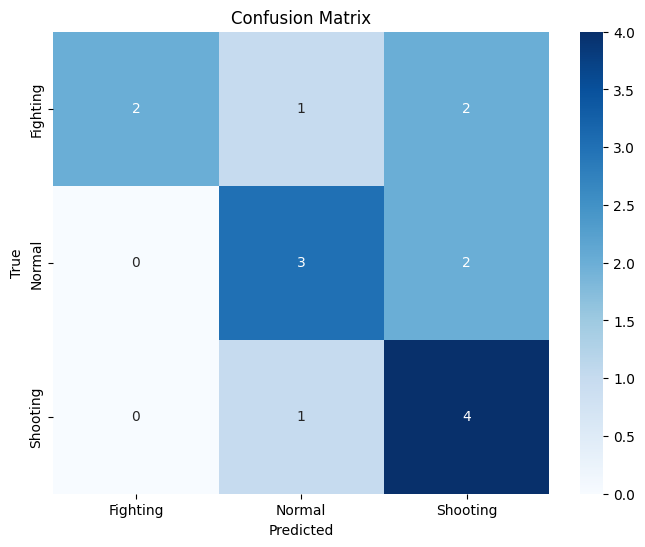

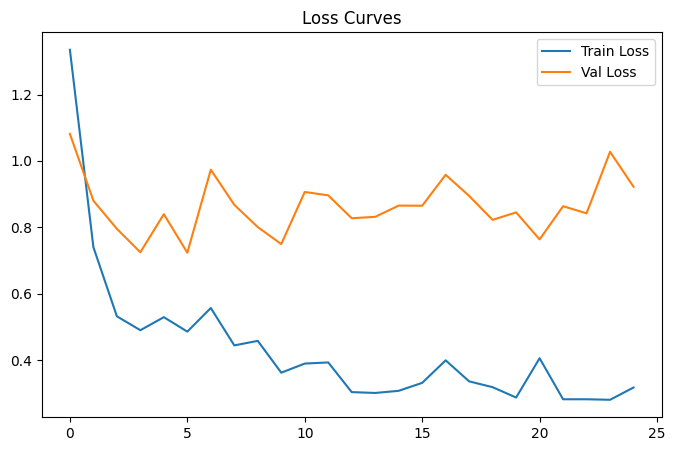


Final Accuracy: 0.6667


In [2]:
import os
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler

from torchvision.models.video import r2plus1d_18
from torchvision.models.video import R2Plus1D_18_Weights

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import VideoFrameDataset

# =========================================================
# CONFIG
# =========================================================

ROOT = "UCF3Class_Balanced"

TRAIN_SPLIT = "Train"
VAL_SPLIT = "Test"

NUM_FRAMES = 16
BATCH_SIZE = 4

EPOCHS = 25

LR = 1e-4
WEIGHT_DECAY = 1e-4

NUM_WORKERS = 4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SAVE_PATH = "best_r2plus1d.pth"

print("Using device:", DEVICE)

# =========================================================
# SEED
# =========================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

# =========================================================
# DATASETS
# =========================================================

train_ds = VideoFrameDataset(
    ROOT,
    split=TRAIN_SPLIT,
    num_frames=NUM_FRAMES,
    train=True
)

val_ds = VideoFrameDataset(
    ROOT,
    split=VAL_SPLIT,
    num_frames=NUM_FRAMES,
    train=False
)

print("Classes:", train_ds.classes)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# =========================================================
# MODEL
# =========================================================

weights = R2Plus1D_18_Weights.DEFAULT

model = r2plus1d_18(weights=weights)

# replace classifier

model.fc = nn.Linear(
    model.fc.in_features,
    len(train_ds.classes)
)

model = model.to(DEVICE)

# =========================================================
# LOSS
# =========================================================

class_weights = torch.tensor(
    [3.0, 1.0, 6.0],
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# =========================================================
# MIXED PRECISION
# =========================================================

scaler = GradScaler()

# =========================================================
# TRAINING
# =========================================================

best_acc = 0.0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    running_loss = 0.0

    start = time.time()

    for xb, yb in train_loader:

        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast():

            out = model(xb)

            loss = criterion(out, yb)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    val_running_loss = 0.0

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            with autocast():

                out = model(xb)

                loss = criterion(out, yb)

            val_running_loss += loss.item()

            preds = out.argmax(1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                yb.cpu().numpy()
            )

    val_loss = val_running_loss / len(val_loader)

    acc = np.mean(
        np.array(preds_all)
        ==
        np.array(labels_all)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {acc:.4f} | "
        f"Time: {(time.time()-start):.1f}s"
    )

    # =====================================================
    # SAVE BEST
    # =====================================================

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        print("Best model saved.")

# =========================================================
# FINAL REPORT
# =========================================================

print("\n================ FINAL REPORT ================\n")

print(classification_report(
    labels_all,
    preds_all,
    target_names=train_ds.classes,
    digits=4
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    labels_all,
    preds_all
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

# =========================================================
# LOSS CURVES
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.title("Loss Curves")

plt.legend()

plt.show()

print(f"\nFinal Accuracy: {best_acc:.4f}")